In [1]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Spotify dataset
df = pd.read_csv("dataset.csv") 

# Inspect data structure
print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSample rows:\n{df.head(3).to_string()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nGenres: {df['track_genre'].nunique()} unique")
print(f"Popularity distribution:\n{df['popularity'].describe()}")

Raw shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Sample rows:
   Unnamed: 0                track_id                 artists        album_name        track_name  popularity  duration_ms  explicit  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence   tempo  time_signature track_genre
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino            Comedy            Comedy          73       230666     False         0.676   0.461    1    -6.746     0       0.1430        0.0322          0.000001     0.358    0.715  87.917               4    acoustic
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward  Ghost (Acoustic)  Ghost - Acoustic          55       149610   

In [3]:
df = (df
      .sort_values("popularity", ascending=False)
      .drop_duplicates(subset="track_id", keep="first")
      .reset_index(drop=True))
print(f"After dedup: {df.shape[0]} unique tracks")

After dedup: 89741 unique tracks


In [4]:
# Select the 10 numeric features that define a song's "Sonic DNA"
FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "popularity"
]

In [5]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(df[FEATURES])
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (89741, 10)


In [6]:
def get_top_similar(track_name: str, artist_hint: str, n: int = 10):
    """
    Returns the top-n most similar tracks to a query track.

    Parameters
    track_name  : str  Exact track name as it appears in the dataset
    artist_hint : str  Substring to filter by artist (handles duplicates)
    n           : int  Number of results to return (default 10)

    Returns
    query_info  : pd.Series  Row for the query track
    results     : pd.DataFrame  Top-n similar tracks with similarity scores
    """
    mask = df["track_name"].eq(track_name) & df["artists"].str.contains(artist_hint)
    if mask.sum() == 0:
        raise ValueError(f"Track not found: '{track_name}' by '{artist_hint}'")

    idx = df[mask].index[0]
    query_vec = X[idx].reshape(1, -1)

    # Cosine similarity: measures angle between vectors (0 = orthogonal, 1 = identical)
    sims = cosine_similarity(query_vec, X)[0]
    sims[idx] = -1  # exclude the query itself
    top_idx = np.argsort(sims)[::-1][:n]
    results = df.iloc[top_idx][["track_name", "artists", "popularity", "track_genre"]].copy()
    results["cosine_similarity"] = sims[top_idx].round(4)
    results.index = range(1, n + 1)
    return df.iloc[idx], results

In [7]:
QUERIES = [ ("Unholy (feat. Kim Petras)", "Sam Smith"), ("As It Was", "Harry Styles"), ("Blinding Lights", "The Weeknd"),]

results_all = {}
for track, artist in QUERIES:
    info, top10 = get_top_similar(track, artist)
    results_all[track] = {"info": info, "top10": top10}
    print(f"\n{'='*60}")
    print(f"QUERY: {track} — {info['artists']}")
    print(f"  popularity={info['popularity']}  genre={info['track_genre']}")
    print(f"  danceability={info['danceability']}  energy={info['energy']}")
    print(f"  valence={info['valence']}  tempo={info['tempo']:.1f} BPM")
    print(f"\nTop 10 Most Similar:")
    print(top10.to_string())


QUERY: Unholy (feat. Kim Petras) — Sam Smith;Kim Petras
  popularity=100  genre=dance
  danceability=0.714  energy=0.472
  valence=0.238  tempo=131.1 BPM

Top 10 Most Similar:
                                          track_name                                                           artists  popularity        track_genre  cosine_similarity
1                                  Seven Nation Army                                                 The White Stripes          84              blues             0.9918
2                                             Shower                                                           Becky G          78          reggaeton             0.9901
3                                              Creep                                                         Radiohead          85           alt-rock             0.9898
4   I Don’t Wanna Live Forever (Fifty Shades Darker)                                                 ZAYN;Taylor Swift          80                p

In [8]:
for track, artist in QUERIES:
    mask = df["track_name"].eq(track) & df["artists"].str.contains(artist)
    idx = df[mask].index[0]
    self_sim = cosine_similarity(X[idx].reshape(1, -1), X[idx].reshape(1, -1))[0][0]
    print(f"Self-similarity for '{track}': {self_sim:.6f} (expected 1.000000)")


Self-similarity for 'Unholy (feat. Kim Petras)': 1.000000 (expected 1.000000)
Self-similarity for 'As It Was': 1.000000 (expected 1.000000)
Self-similarity for 'Blinding Lights': 1.000000 (expected 1.000000)


In [9]:
for track in results_all:
    scores = results_all[track]["top10"]["cosine_similarity"]
    assert scores.between(0, 1).all(), f"Out-of-range similarity scores for {track}!"
    print(f"'{track}' scores in [0,1]: PASS (min={scores.min()}, max={scores.max()})")

'Unholy (feat. Kim Petras)' scores in [0,1]: PASS (min=0.9885, max=0.9918)
'As It Was' scores in [0,1]: PASS (min=0.9903, max=0.9999)
'Blinding Lights' scores in [0,1]: PASS (min=0.9949, max=0.9974)


Saved: fig1_similarity_bars.png


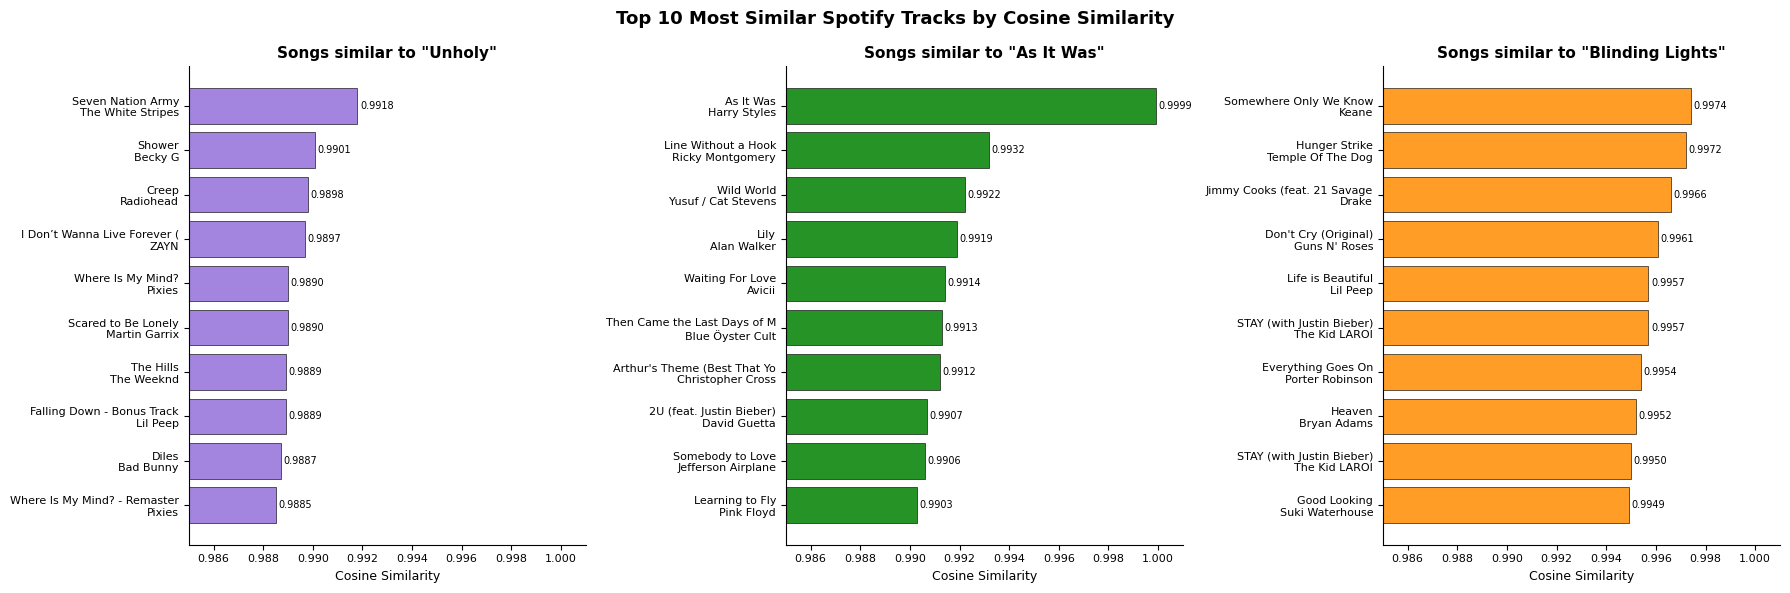

In [10]:
colors = {
    "Unholy (feat. Kim Petras)": "mediumpurple",
    "As It Was":                 "green",
    "Blinding Lights":           "darkorange",
}
labels_short = {
    "Unholy (feat. Kim Petras)": "Unholy",
    "As It Was":                 "As It Was",
    "Blinding Lights":           "Blinding Lights",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("white")

for ax, (track, artist) in zip(axes, QUERIES):
    top10 = results_all[track]["top10"].copy()

    top10["label"] = top10.apply(
        lambda r: f"{r['track_name'][:28]}\n{r['artists'].split(';')[0][:22]}",
        axis=1
    )

    color = colors[track]

    bars = ax.barh(
        range(10),
        top10["cosine_similarity"],
        color=color,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_yticks(range(10))
    ax.set_yticklabels(top10["label"].tolist(), fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0.985, 1.001)
    ax.set_xlabel("Cosine Similarity", fontsize=9)
    ax.set_title(f'Songs similar to "{labels_short[track]}"',
                 fontsize=11, fontweight="bold")

    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=8)

    for bar, val in zip(bars, top10["cosine_similarity"]):
        ax.text(val + 0.0001,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}",
                va="center",
                fontsize=7,
                color="black")

plt.suptitle(
    "Top 10 Most Similar Spotify Tracks by Cosine Similarity",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig1_similarity_bars.png", dpi=150)
print("Saved: fig1_similarity_bars.png")

Saved: fig2_radar_chart.png
Saved: fig3_genre_distribution.png


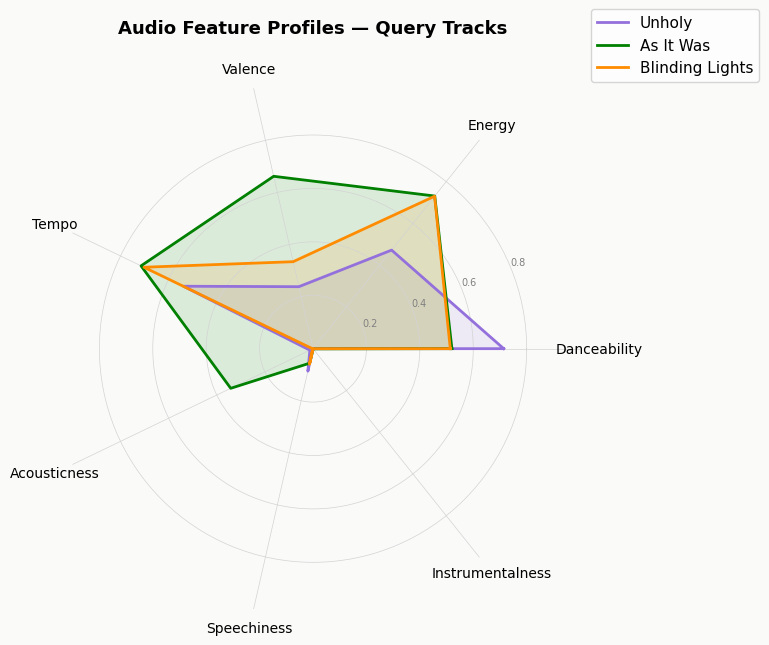

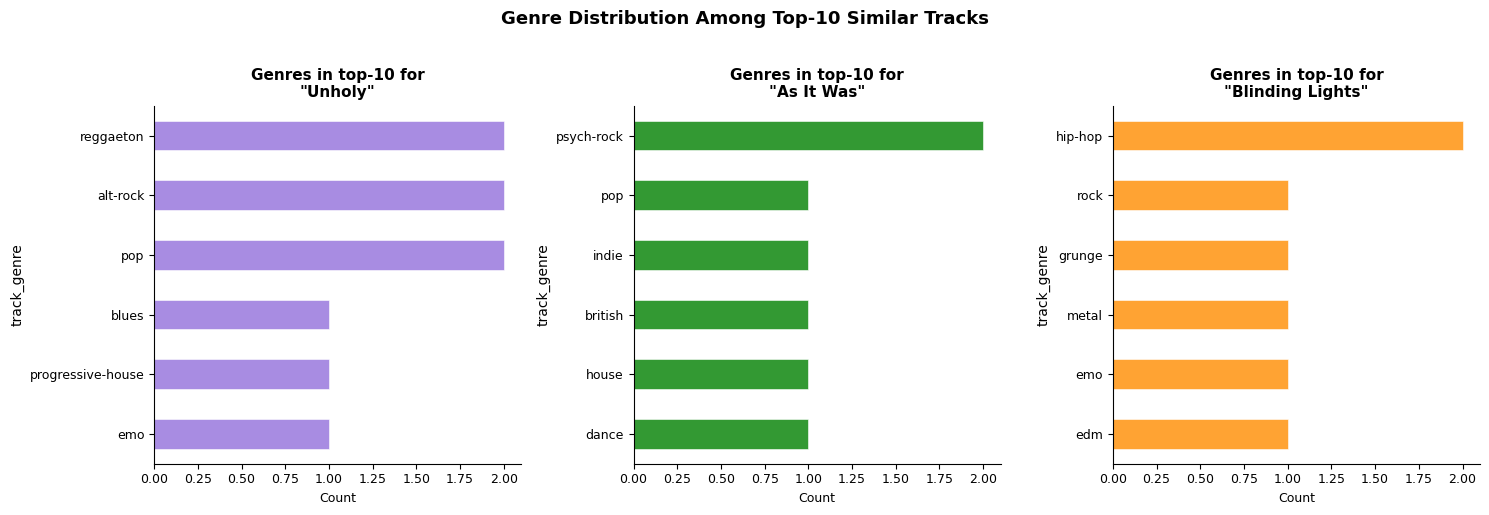

In [11]:
radar_features = [
    "danceability", "energy", "valence", "tempo_norm",
    "acousticness", "speechiness", "instrumentalness"
]
feature_labels = ["Danceability", "Energy", "Valence", "Tempo",
                  "Acousticness", "Speechiness", "Instrumentalness"]

# Normalize tempo separately for radar display
df["tempo_norm"] = (df["tempo"] - df["tempo"].min()) / (df["tempo"].max() - df["tempo"].min())

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#FAFAF9")
ax.set_facecolor("#FAFAF9")

query_colors = ["mediumpurple", "green", "darkorange"]
query_names  = ["Unholy", "As It Was", "Blinding Lights"]

for (track, artist), color, name in zip(QUERIES, query_colors, query_names):
    mask = df["track_name"].eq(track) & df["artists"].str.contains(artist)
    row = df[mask].iloc[0]
    values = [row[f] for f in radar_features] + [row[radar_features[0]]]
    ax.plot(angles, values, color=color, linewidth=2, linestyle="solid", label=name)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=7, color="gray")
ax.grid(color="lightgray", linewidth=0.5)
ax.spines["polar"].set_visible(False)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_title("Audio Feature Profiles — Query Tracks\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_radar_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: fig2_radar_chart.png")


#Visualization 3: Genre Distribution of Top 10 Results 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("white")

for ax, (track, artist), color, name in zip(axes, QUERIES, query_colors, query_names):
    genre_counts = (results_all[track]["top10"]["track_genre"]
                    .value_counts()
                    .head(6))
    genre_counts.plot(kind="barh", ax=ax, color=color, alpha=0.8,
                      edgecolor="white", linewidth=0.5)
    ax.invert_yaxis()
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Count", fontsize=9)
    ax.set_title(f'Genres in top-10 for\n"{name}"', fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)

plt.suptitle("Genre Distribution Among Top-10 Similar Tracks",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig3_genre_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="white")
print("Saved: fig3_genre_distribution.png")